In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

**Trying on with background subtraction**

In [5]:
reference_image=r"C:\ALL PROJECTS\MCCB-Defect-Detection\images\mccb(R).png"
test_image=r"C:\ALL PROJECTS\MCCB-Defect-Detection\images\mccb(T).png"

In [6]:
reference=cv2.imread(reference_image,0)
print(reference.shape)




(1024, 1024)


In [7]:
test=cv2.imread(test_image,0)
print(test.shape)

(1024, 1024)


In [8]:
test=cv2.resize(test,(reference.shape[1],reference.shape[0]))
print(test.shape)

(1024, 1024)


In [9]:
test = cv2.GaussianBlur(test, (5,5), 0)
reference = cv2.GaussianBlur(reference, (5,5), 0)


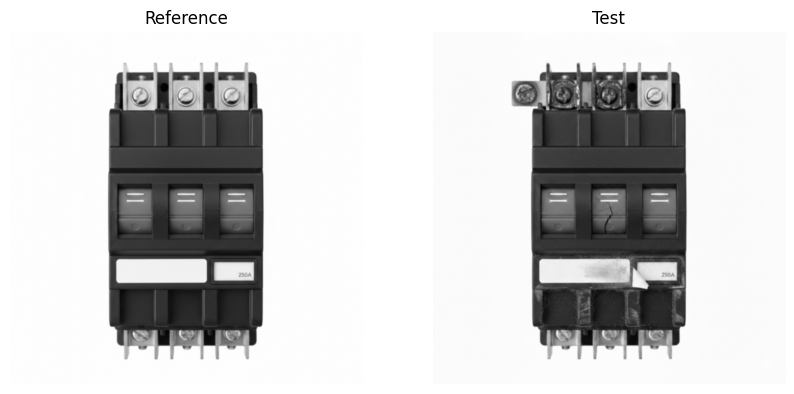

In [10]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
ax1.imshow(reference,cmap='gray')
ax1.set_title('Reference')
ax2.imshow(test,cmap='gray')
ax2.set_title('Test')
ax1.axis('off')
ax2.axis('off')
plt.show()

In [11]:
diff1=cv2.absdiff(reference,test)
diff0=cv2.absdiff(reference,test)
_,mask=cv2.threshold(diff1,30,255,cv2.THRESH_BINARY)

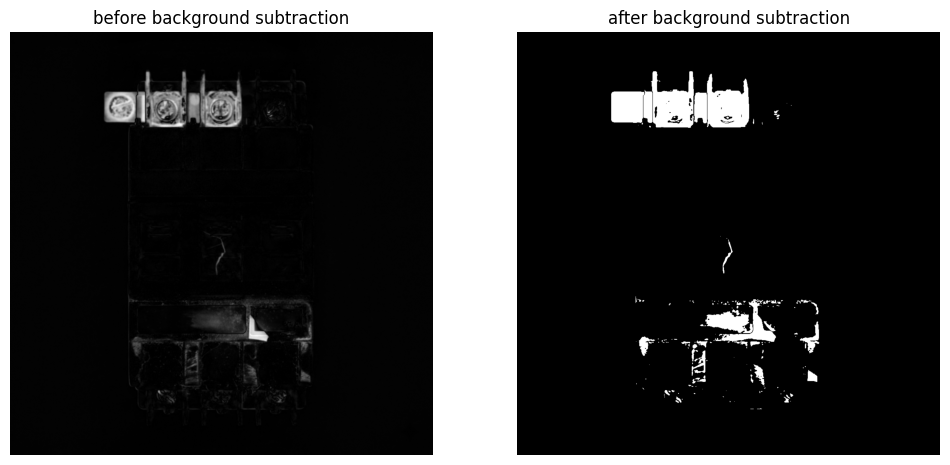

In [12]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,6))
ax1.imshow(diff0,cmap='gray')
ax2.imshow(mask,cmap='gray')
ax1.set_title("before background subtraction")
ax2.set_title("after background subtraction")
ax1.axis('off')
ax2.axis('off')
plt.show()


In [13]:
kernel=np.ones((3,3),np.uint8)
clean_mask=cv2.medianBlur(mask, 5)

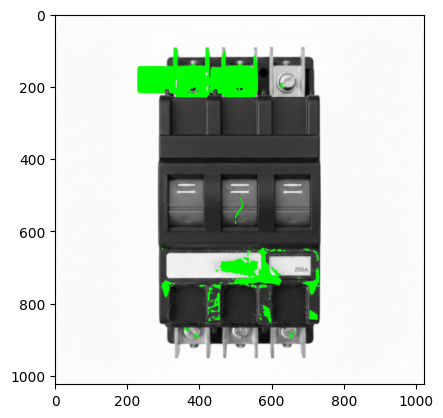

In [14]:
test_color=cv2.cvtColor(test,cv2.COLOR_GRAY2BGR)
test_color[clean_mask==255]=(0,255,0)
plt.imshow(test_color)

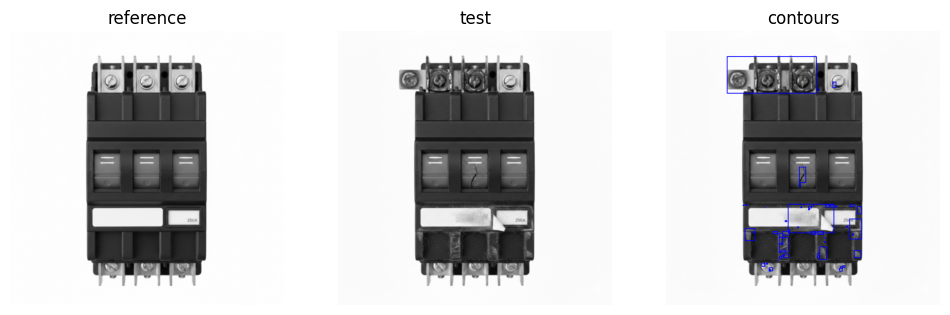

In [15]:
contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
test_color=cv2.cvtColor(test,cv2.COLOR_GRAY2BGR)
for cnt in contours:
    x,y,w,h=cv2.boundingRect(cnt)
    cv2.rectangle(test_color,(x,y),(x+w,y+h),(0,0,255),2)
fig,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(12,6))
ax1.imshow(reference,cmap='gray')
ax2.imshow(test,cmap='gray')
ax3.imshow(test_color)
ax1.set_title("reference")
ax2.set_title("test")
ax3.set_title("contours")
ax1.axis('off')
ax2.axis('off')
ax3.axis('off')
plt.show()

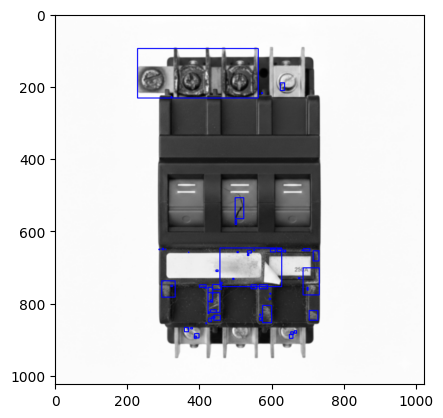

In [16]:
plt.imshow(test_color)
plt.show()

**Trying on with a new pipeline**